In [6]:
from sklearn.metrics import *
import numpy as np

np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:,.2f}'.format

In [7]:
import pandas as pd
from ESRNN import ESRNN
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN.utils_visualization import plot_grid_prediction




# Load your time series data
# Ensure your dataframe has 'unique_id', 'ds' (date), and 'y' (value) columns
df = pd.read_excel('preprocessedBelgeler/ES_RNN Adjusted.xlsx')
df['unique_id'] = df['unique_id'].astype(str)

"""
# Her unique_id için y=0 olan satırların sayısını hesapla
zero_counts = df[df['y'] == 0].groupby('unique_id').size()

# y=0 sayısı 24'ten büyük olan unique_id'leri bul
ids_with_many_zeros = zero_counts[zero_counts > 24].index

# Bu id'lere sahip tüm verileri çıkararak filtrele
df = df[~df['unique_id'].isin(ids_with_many_zeros)]
"""




# Remove rows where y is zero
df['y'] = df['y'].replace(0, 0.01)

zero_mask = df['y'] == 0
num_zeros = zero_mask.sum()


df = df.sort_values(by=["unique_id", "ds"])

#df['y'] = 50*df['y']

# Split data into training and testing sets

#train_df = df[(df['ds'] >= '2020-01-01') & (df['ds'] <= '2023-12-31')]
train_df = df[(df['ds'] >= '2021-01-01') & (df['ds'] < '2024-01-01')]
test_df = df[(df['ds'] > '2024-12-31') & (df['ds'] < '2025-04-01')]

#X_train_df = train_df[X_columns].reset_index(drop=True)
#y_train_df = train_df[y_column].reset_index(drop=True)


# Define Features (X) and Target (y)
X_columns = ["unique_id","ds", "x"]  # Features
y_column = [ "unique_id","ds","y"]  # Target variable


model = ESRNN(max_epochs=5, 
              # frequency of computing and reporting this loss
              freq_of_test=1, 
              batch_size=4, 
              
              # customize things around the learning rate
              learning_rate=0.001, per_series_lr_multip=0.5,
              lr_scheduler_step_size=7, lr_decay=0.5, 
              
              gradient_clipping_threshold=5, 
              rnn_weight_decay=0.0, noise_std=0.001, 
              level_variability_penalty=30, 
              
              # for probabilistic forecasting
              testing_percentile=10, training_percentile=50,
              
              ensemble=True, max_periods=70, 
              seasonality=[12], input_size=12, output_size=16,
              cell_type='LSTM', state_hsize=40, 
               
              add_nl_layer=False,
              random_seed=1, device='cpu')




# Split into X and y for training and testing
X_train_df = train_df[X_columns].reset_index(drop=True)
y_train_df = train_df[y_column].reset_index(drop=True)

print(y_train_df)
X_test_df = test_df[X_columns]
y_test_df = test_df[y_column]


"""
X_train_df = train_df[X_columns].reset_index(drop=True)
y_train_df = train_df[y_column].reset_index(drop=True)
"""


# Fit the model
model.fit(X_train_df, y_train_df)





print(X_test_df)
y_hat = model.predict(X_test_df)
print(y_hat)


      unique_id         ds      y
0             1 2021-01-01 398.00
1             1 2021-02-01 110.00
2             1 2021-03-01  40.00
3             1 2021-04-01   0.01
4             1 2021-05-01   0.01
...         ...        ...    ...
47623       999 2023-08-01   0.01
47624       999 2023-09-01   0.01
47625       999 2023-10-01   0.01
47626       999 2023-11-01   0.01
47627       999 2023-12-01   0.01

[47628 rows x 3 columns]
Infered frequency: MS
=============== Training ESRNN  ===============

========= Epoch 0 finished =========
Training time: 2.75054
Training loss (50 prc): 197.76450
========= Epoch 1 finished =========
Training time: 2.74231
Training loss (50 prc): 196.57852
========= Epoch 2 finished =========
Training time: 2.74653
Training loss (50 prc): 195.45309
========= Epoch 3 finished =========
Training time: 2.71617
Training loss (50 prc): 194.20761
========= Epoch 4 finished =========
Training time: 2.57793
Training loss (50 prc): 193.02733
Train finished! 

      u

In [8]:
comparison_df = y_hat.merge(y_test_df, on=['unique_id', 'ds'], how='left')
print(comparison_df)
def save_datasets(comparison_df, folder_path="/Users/cankocak/Desktop/Spring25/"):
    
    
    import os
    os.makedirs(folder_path, exist_ok=True)  # Ensure directory exists

    # Save DataFrames
    comparison_df.to_csv(f"{folder_path}comparison_df.csv", index=False)

    print(f"Data saved in '{folder_path}' before running the model.")

# Save Data Before Running the Model
save_datasets(comparison_df)

print(y_hat)

     unique_id         ds        x  y_hat     y
0            1 2025-01-01  DX51D+Z  11.94 60.00
1            1 2025-02-01  DX51D+Z  13.44  0.01
2            1 2025-03-01  DX51D+Z   3.88 20.00
3           10 2025-01-01  DX51D+Z   0.01  0.01
4           10 2025-02-01  DX51D+Z   0.01  0.01
...        ...        ...      ...    ...   ...
3964       998 2025-02-01   DD11-1   0.01  0.01
3965       998 2025-03-01   DD11-1   0.01  0.01
3966       999 2025-01-01   DD11-1   0.02  0.01
3967       999 2025-02-01   DD11-1   0.01  0.01
3968       999 2025-03-01   DD11-1   0.01  0.01

[3969 rows x 5 columns]
Data saved in '/Users/cankocak/Desktop/Spring25/' before running the model.
     unique_id         ds        x  y_hat
0            1 2025-01-01  DX51D+Z  11.94
1            1 2025-02-01  DX51D+Z  13.44
2            1 2025-03-01  DX51D+Z   3.88
3           10 2025-01-01  DX51D+Z   0.01
4           10 2025-02-01  DX51D+Z   0.01
...        ...        ...      ...    ...
3964       998 2025-02-01   D

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# Önce gerçek verileri filtrele
filtered_true = y_test_df[y_test_df['y'] > -0.01][['unique_id', 'ds', 'y']]

# Tahmin edilen verileri al
pred_df = y_hat[['unique_id', 'ds', 'y_hat']]

# Hem unique_id hem de Month'a göre eşleşen verileri merge ile bul
merged_df = pd.merge(filtered_true, pred_df, on=['unique_id', 'ds'], how='inner')

# Elde edilen eşleşmiş değerlerle metrikleri hesapla
y_true = merged_df['y']
y_pred = merged_df['y_hat']

mae_filtered = mean_absolute_error(y_true, y_pred)
mape_filtered = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse_filtered = np.sqrt(mean_squared_error(y_true, y_pred))
smape_filtered = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
wmape_filtered = 100 * np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true))

# Sonuçları yazdır
print(f"Eşleşen satır sayısı: {len(merged_df)}")
print(f"📉 Filtrelenmiş MAE   : {mae_filtered:.4f}")
print(f"📊 Filtrelenmiş MAPE  : {mape_filtered:.2f}%")
print(f"📐 Filtrelenmiş RMSE  : {rmse_filtered:.4f}")
print(f"🔁 Filtrelenmiş sMAPE : {smape_filtered:.2f}%")
print(f"⚖️  Filtrelenmiş wMAPE : {wmape_filtered:.2f}%")

# Sonucu Excel'e kaydetmek istersen
merged_df.to_excel("matched_y_true_vs_y_hat.xlsx", index=False)




Eşleşen satır sayısı: 3969
📉 Filtrelenmiş MAE   : 25.3574
📊 Filtrelenmiş MAPE  : 6427.28%
📐 Filtrelenmiş RMSE  : 187.9444
🔁 Filtrelenmiş sMAPE : 73.30%
⚖️  Filtrelenmiş wMAPE : 74.87%


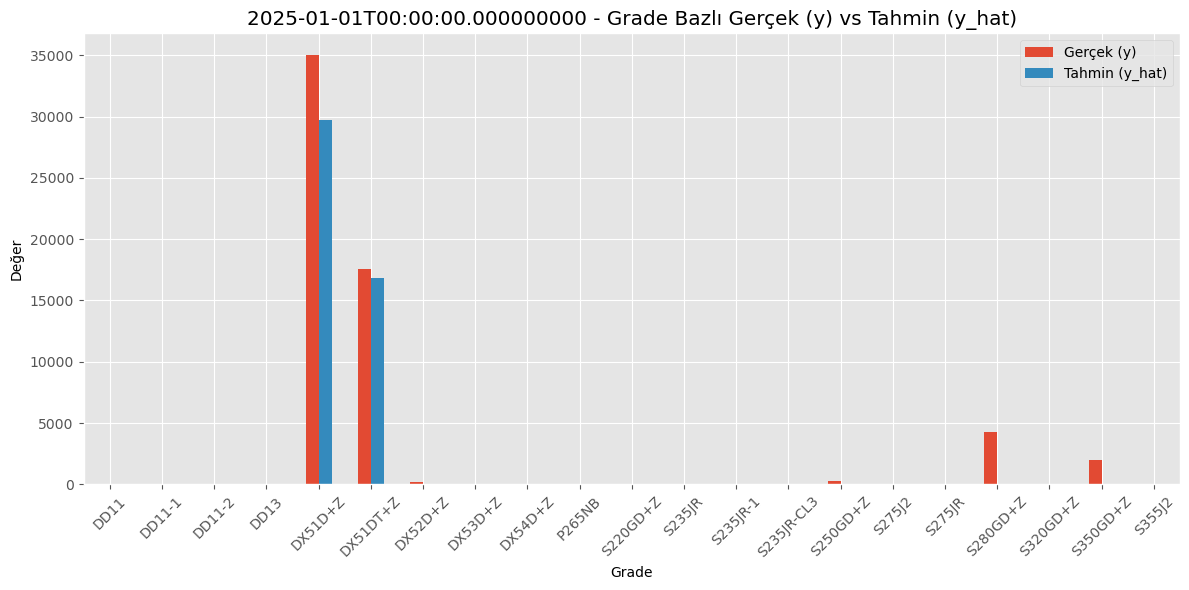

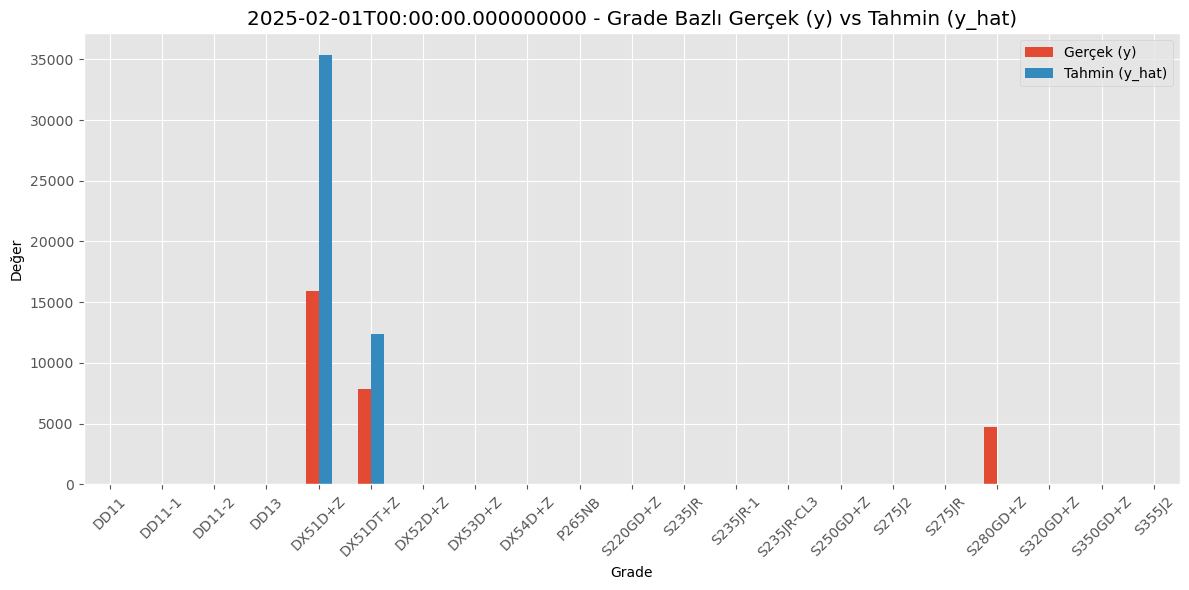

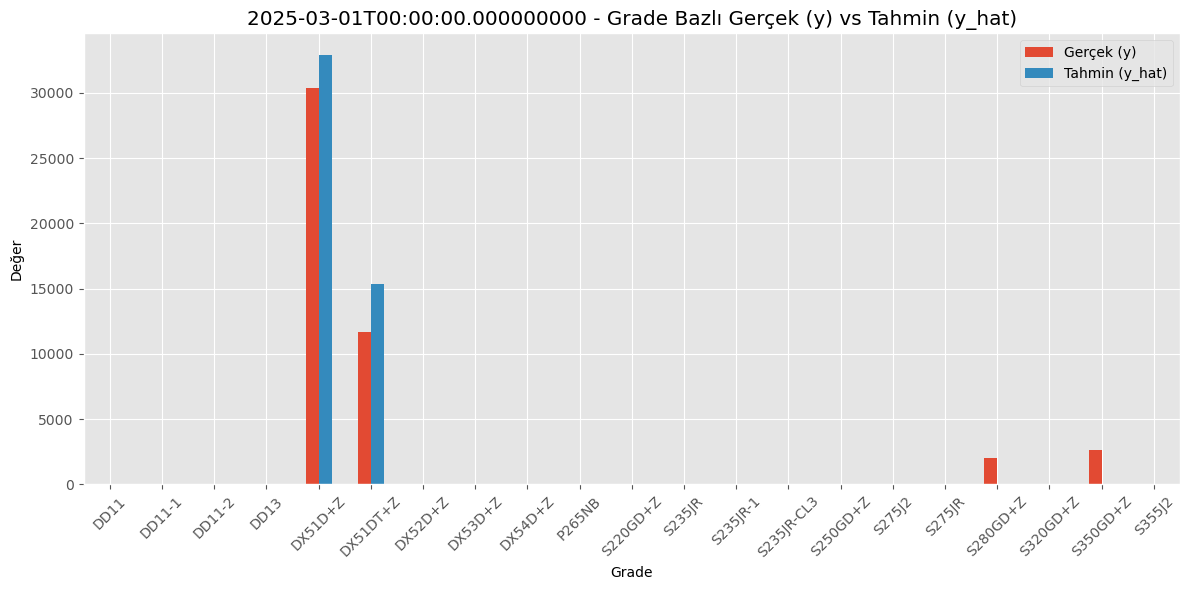

In [18]:

# unique_id ve ds'e göre left join
merged_df = pd.merge(y_test_df, y_hat, on=['unique_id', 'ds'], how='left')
mergeeee = merged_df
aggregated_df_y_hat = merged_df.groupby(['ds', 'x'])['y_hat'].sum().reset_index()

aggregated_df_y = merged_df.groupby(['ds', 'x'])['y'].sum().reset_index()

import pandas as pd
import matplotlib.pyplot as plt

# Ortaklaştır
merged_df = pd.merge(aggregated_df_y, aggregated_df_y_hat, on=['ds', 'x'], how='inner')

# Her ay (ds) için ayrı grafik çiz
for ds_value in merged_df['ds'].unique():
    subset = merged_df[merged_df['ds'] == ds_value].set_index('x')
    
    subset[['y', 'y_hat']].plot(kind='bar', figsize=(12, 6))
    plt.title(f"{ds_value} - Grade Bazlı Gerçek (y) vs Tahmin (y_hat)")
    plt.ylabel("Değer")
    plt.xlabel("Grade")
    plt.xticks(rotation=45)
    plt.legend(["Gerçek (y)", "Tahmin (y_hat)"])
    plt.tight_layout()
    plt.show()



In [20]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np

# Gerçek ve tahmin değerlerini al
y_true_agg = mergeeee['y']
y_pred_agg = mergeeee['y_hat']
print(mergeeee)
# 📐 Error metric hesaplamaları
mae_agg = mean_absolute_error(y_true_agg, y_pred_agg)
mape_agg = mean_absolute_percentage_error(y_true_agg, y_pred_agg) * 100
rmse_agg = np.sqrt(mean_squared_error(y_true_agg, y_pred_agg))
smape_agg = 100 * np.mean(2 * np.abs(y_pred_agg - y_true_agg) / (np.abs(y_true_agg) + np.abs(y_pred_agg)))
wmape_agg = 100 * np.sum(np.abs(y_pred_agg - y_true_agg)) / np.sum(np.abs(y_true_agg))

# 🔢 Sonuçları yazdır
print(f"\n📦 Grade + Tarih bazlı toplulaştırılmış tahmin performansı:")
print(f"MAE   : {mae_agg:.4f}")
print(f"MAPE  : {mape_agg:.2f}%")
print(f"sMAPE : {smape_agg:.2f}%")
print(f"wMAPE : {wmape_agg:.2f}%")
print(f"RMSE  : {rmse_agg:.4f}")


     unique_id         ds     y        x  y_hat
0            1 2025-01-01 60.00  DX51D+Z  11.94
1            1 2025-02-01  0.01  DX51D+Z  13.44
2            1 2025-03-01 20.00  DX51D+Z   3.88
3           10 2025-01-01  0.01  DX51D+Z   0.01
4           10 2025-02-01  0.01  DX51D+Z   0.01
...        ...        ...   ...      ...    ...
3964       998 2025-02-01  0.01   DD11-1   0.01
3965       998 2025-03-01  0.01   DD11-1   0.01
3966       999 2025-01-01  0.01   DD11-1   0.02
3967       999 2025-02-01  0.01   DD11-1   0.01
3968       999 2025-03-01  0.01   DD11-1   0.01

[3969 rows x 5 columns]

📦 Grade + Tarih bazlı toplulaştırılmış tahmin performansı:
MAE   : 25.3574
MAPE  : 6427.28%
sMAPE : 73.30%
wMAPE : 74.87%
RMSE  : 187.9444


In [11]:
# Filtreleme koşulu
filtered_indices = y_test_df['y'] > 0.1

# Yalnızca koşula uyan gerçek değerleri seç
filtered_y_true = y_test_df.loc[filtered_indices, 'y']

# Ortak indexlerde kesişim yaparak tahmin değerlerini seç
common_indices = filtered_y_true.index.intersection(y_hat.index)

# Ortak indexler ile filtrelenmiş değerler
filtered_y_true = y_test_df.loc[common_indices, 'y']
filtered_y_pred = y_hat.loc[common_indices, 'y_hat']
filtered_unique_ids = y_test_df.loc[common_indices, 'unique_id']

# Sonuçları içeren DataFrame oluştur
filtered_results_df = pd.DataFrame({
    'unique_id': filtered_unique_ids,
    'y_true': filtered_y_true,
    'y_predicted': filtered_y_pred
})

# Excel dosyasına kaydet
filtered_results_df.to_excel('filtered_true_vs_predicted_with_id.xlsx', index=False)


In [ ]:
import pandas as pd
import numpy as np
from ESRNN.utils_evaluation import evaluate_prediction_owa

# 🔧 1. Tipleri eşitle
for df in [y_hat, y_test_df, y_train_df]:
    df['unique_id'] = df['unique_id'].astype(str)
    df['ds'] = pd.to_datetime(df['ds'])

# 🔧 2. Sadece gerekli kolonlar
y_hat_clean = y_hat[['unique_id', 'ds', 'y_hat']].sort_values(['unique_id', 'ds']).reset_index(drop=True)
y_test_clean = y_test_df[['unique_id', 'ds', 'y']].sort_values(['unique_id', 'ds']).reset_index(drop=True)
y_train_clean = y_train_df[['unique_id', 'ds', 'y']].sort_values(['unique_id', 'ds']).reset_index(drop=True)

# 🔍 3. Uyumlu index ve tip kontrolü (hata almamak için)
assert 'y_hat' in y_hat_clean.columns
assert y_hat_clean['unique_id'].is_monotonic_increasing
assert y_test_clean['unique_id'].is_monotonic_increasing
assert y_hat_clean.shape[0] == y_test_clean.shape[0], "Tahmin ve gerçek test verisi uyumsuz!"

# ✅ 4. Evaluation çağrısı
final_owa, final_mase, final_smape = evaluate_prediction_owa(
    y_hat_df=y_hat_clean,
    y_train_df=y_train_clean,
    X_test_df=X_test_df,
    y_test_df=y_test_clean,
    naive2_seasonality=12
)

# 🎯 5. Sonuçları yazdır
print("\n✅ Evaluation Results:")
print(f"📦 OWA   : {final_owa:.4f}")
print(f"📏 MASE  : {final_mase:.4f}")
print(f"📈 sMAPE : {final_smape:.2f}%")




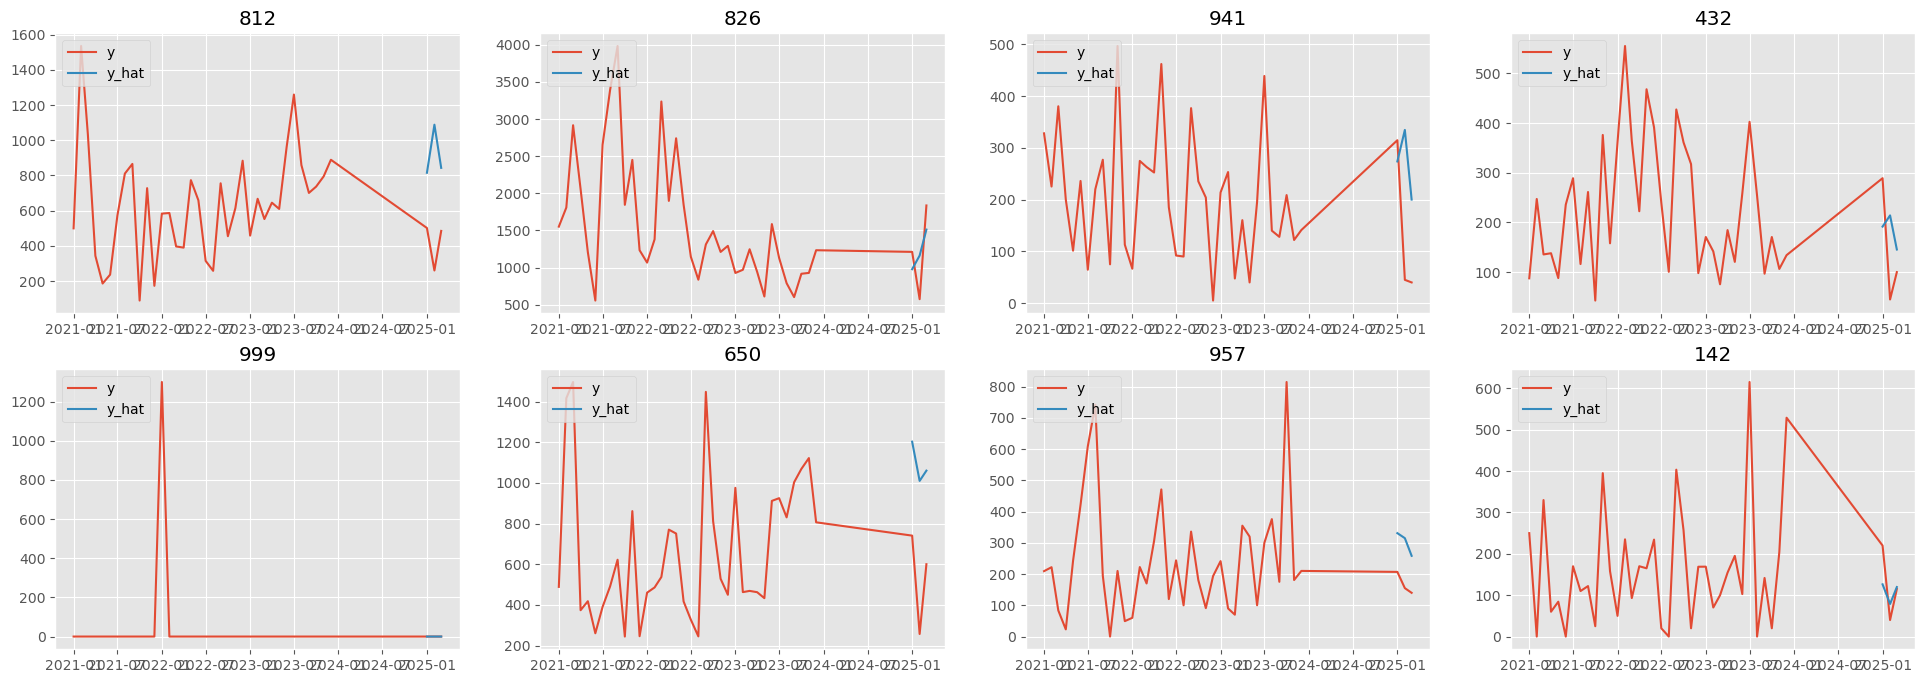

In [170]:
unique_ids = ['432', '957', '650', '142', '826', '812', '941', '999']

plot_preds = pd.concat([y_train_df.groupby('unique_id').tail(50), 
                        y_test_df],  sort=True)

plot_grid_prediction(plot_preds, y_hat,  unique_ids=unique_ids)

In [104]:
# Function to save datasets
def save_datasets(X_train_df, y_train_df, X_test_df, y_test_df, folder_path="/Users/cankocak/Desktop/Spring25/"):
    
    
    import os
    os.makedirs(folder_path, exist_ok=True)  # Ensure directory exists

    # Save DataFrames
    X_train_df.to_csv(f"{folder_path}X_train_df.csv", index=False)
    y_train_df.to_csv(f"{folder_path}y_train_df.csv", index=False)
    X_test_df.to_csv(f"{folder_path}X_test_df.csv", index=False)
    y_test_df.to_csv(f"{folder_path}y_test_df.csv", index=False)

    print(f"Data saved in '{folder_path}' before running the model.")

# Ensure Data Is Clean Before Saving
X_train_df = X_train_df.dropna().reset_index(drop=True)
y_train_df = y_train_df.dropna().reset_index(drop=True)
X_test_df = X_test_df.dropna().reset_index(drop=True)
y_test_df = y_test_df.dropna().reset_index(drop=True)

# Save Data Before Running the Model
save_datasets(X_train_df, y_train_df, X_test_df, y_test_df)

Data saved in '/Users/cankocak/Desktop/Spring25/' before running the model.


In [ ]:
# Generate forecasts
forecasts = model.predict(X_test_df, y_test_df)
print(forecasts[:1000])

In [64]:
from ESRNN import ESRNN
from ESRNN.m4_data import *
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN.utils_visualization import plot_grid_prediction


X_train_df, y_train_df, X_test_df, y_test_df = prepare_m4_data( dataset_name="Monthly", 
   directory="/Users/cankocak/Desktop/Spring25/INDR491/m4 Dataset", 
   num_obs=414)
print(y_train_df.head(50000))

# Initialize the ESRNN model
model = ESRNN(max_epochs=5, 
              # frequency of computing and reporting this loss
              freq_of_test=1, 
              batch_size=32, 
              
              # customize things around the learning rate
              learning_rate=0.02, per_series_lr_multip=0.5,
              lr_scheduler_step_size=7, lr_decay=0.5, 
              
              gradient_clipping_threshold=50, 
              rnn_weight_decay=0.0, noise_std=0.001, 
              level_variability_penalty=30, 
              
              # for probabilistic forecasting
              testing_percentile=50, training_percentile=50,
              
              ensemble=True, max_periods=371, 
              seasonality=[12], input_size=12, output_size=24,
              cell_type='LSTM', state_hsize=40, 
              dilations=[[1, 4, 24, 168]], 
              add_nl_layer=False,
              random_seed=1, device='cpu')

# Fit the model
model.fit(X_train_df, y_train_df)

#Predict on test set
y_hat_df = model.predict(X_test_df)
print(y_hat_df)
# Evaluate predictions
final_owa, final_mase, final_smape = evaluate_prediction_owa(y_hat_df, y_train_df, 
                                                             X_test_df, y_test_df,
                                                             naive2_seasonality=24)



      unique_id         ds       y
0            M1 1970-01-31  8000.0
1            M1 1970-02-28  8350.0
2            M1 1970-03-31  8570.0
3            M1 1970-04-30  7700.0
4            M1 1970-05-31  7080.0
...         ...        ...     ...
49995      M208 1980-10-31   649.0
49996      M208 1980-11-30   651.0
49997      M208 1980-12-31   655.0
49998      M208 1981-01-31   660.0
49999      M208 1981-02-28   666.0

[50000 rows x 3 columns]
Infered frequency: M
=============== Training ESRNN  ===============

========= Epoch 0 finished =========
Training time: 0.60018
Training loss (50 prc): 0.29084
========= Epoch 1 finished =========
Training time: 0.62344
Training loss (50 prc): 0.30039
========= Epoch 2 finished =========
Training time: 0.6354
Training loss (50 prc): 0.27509
========= Epoch 3 finished =========
Training time: 0.65004
Training loss (50 prc): 0.26180
========= Epoch 4 finished =========
Training time: 0.52492
Training loss (50 prc): 0.25793
Train finished! 

     

AttributeError: module 'numpy' has no attribute 'asscalar'

In [36]:
import pandas as pd
import numpy as np

# Load existing dataset
file_path = "preprocessedBelgeler/filled_ES_RNN.xlsx"  # Update with your actual file path
df = pd.read_excel(file_path)

# Convert 'ds' to datetime
df['ds'] = pd.to_datetime(df['ds'])

# Find the earliest date in the dataset
earliest_date = df['ds'].min()

# Generate 300 months back from the earliest date
months_back = 300
new_dates = pd.date_range(end=earliest_date, periods=months_back, freq='MS')

# Create a new DataFrame for expanded data
expanded_data = []

for unique_id in df['unique_id'].unique():
    x_value = df[df['unique_id'] == unique_id]['x'].iloc[0]  # Preserve 'x' value
    for date in new_dates:
        random_y = np.random.randint(1, 500)  # Generate a random y value
        expanded_data.append([date, unique_id, random_y, x_value])

# Convert list to DataFrame
df_expanded = pd.DataFrame(expanded_data, columns=['ds', 'unique_id', 'y', 'x'])

# Combine with original dataset
df_final = pd.concat([df, df_expanded]).drop_duplicates(subset=['ds', 'unique_id']).sort_values(['unique_id', 'ds'])

# Save to new file
df_final.to_excel("preprocessedBelgeler/expanded_data.xlsx", index=False)

print("Dataset expanded successfully. Check 'expanded_data.xlsx'")


Dataset expanded successfully. Check 'expanded_data.xlsx'
